# TN2211 Session 1

## Testing the installation on your computer

In [1]:
import sys
sys.path.append("../drivers/")
from tn2211_drivers import *
import glob
import matplotlib.pyplot as plt

Loading BokehJS ...

In [2]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL1::INSTR',
 'ASRL2::INSTR',
 'ASRL3::INSTR',
 'ASRL4::INSTR',
 'USB0::0xF4EC::0x1103::SDG1XDDQ802940::INSTR',
 'USB0::0xF4EC::0x1201::SDM35HBQ802212::INSTR',
 'USB0::0xF4EC::0x1017::SDS08A0Q808362::INSTR')

# Basic instrument driver examples

## Scope

### Making a connection

The first step is to create the scope object, which also opens the connection, based on the first device in the devices list that matches the keyword string:

In [3]:
scope = Scope("SDS")

Connecting to scope at resource: USB0::0xF4EC::0x1017::SDS08A0Q808362::INSTR


**Important!** Once you connect to instruments from your notebook by opening one of the "resources", that resource is locked and cannot be used by other notebooks / python kernels until either you close the resource or you restart the kernel. 

If you get an error in the above command, then it is likely there is a notebook running on your computer that is already connected to that instrument. You can disconnect the other python kernel by restarting the kernel of the other notebook, or by running `scope.dev.close()` in the other kernel if you do not want to restart it.

The first fun and easy command in the device driver is taking screenshots:

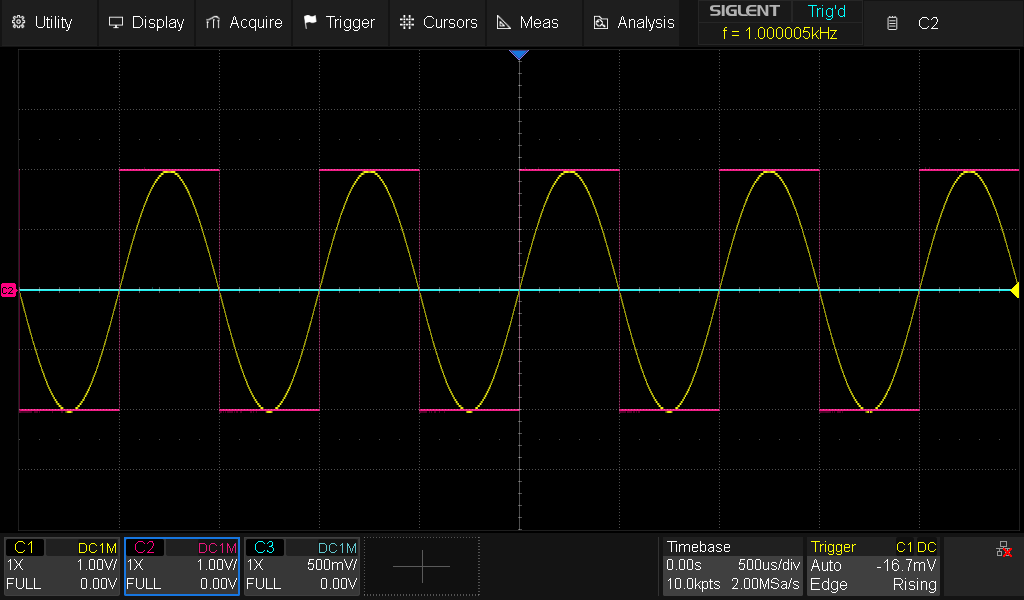

In [4]:
scope.get_screenshot()

Note that by default, it will also **save** your screenshot to the current folder with an automatically generated file name!

In [5]:
glob.glob("scope_screenshot*.png")

['scope_screenshot_2025-09-19-14.32.05.png',
 'scope_screenshot_2025-09-19-14.04.58.png',
 'scope_screenshot_2025-09-19-14.15.25.png',
 'scope_screenshot_2025-09-19-14.19.06.png']

### Grabbing a trace

The next useful function implemented in the driver library is th ability to grab the trace from channels 1 to 4:

In [6]:
t,v = scope.get_trace(1)

Total trace points: 10000
Retreiving 10000 points


By default, the code will return only the first 10000 points of the trace: the reason is that trasferring larger traces (100M points) over USB can be very slow (take up to 30 seconds?) and also the pyton plotting also becomes very slow with more than 10000 points. But you can override this with an optional parameter in the function:

In [7]:
help(scope.get_trace)

Help on method get_trace in module tn2211_drivers:

get_trace(channel_number, npoints=10000, save_file=True) method of tn2211_drivers.Scope instance



Also, like the screnshot, this will also by default save the data from your trace to a time-stamped datafile in your folder. If you work carefully with timestamps in your logbook, this will allow you to figure out what all these data file contain. 

In [8]:
glob.glob("scope_trace*.dat")

['scope_trace_2025-09-19-14.32.05.dat',
 'scope_trace_2025-09-19-14.07.43.dat',
 'scope_trace_2025-09-19-14.15.25.dat',
 'scope_trace_2025-09-19-14.19.11.dat']

For plotting the data, you can use the usual `matplotlib` routines that you likely know from other courses:

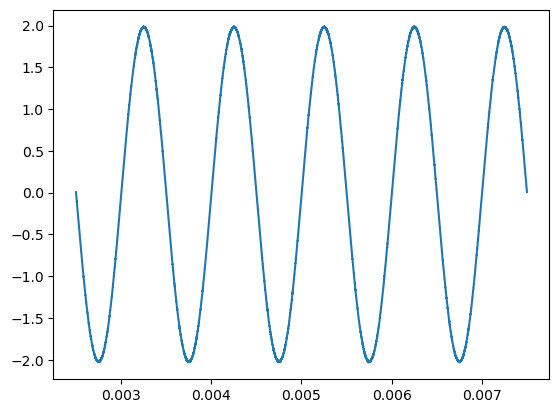

In [9]:
plt.plot(t,v)

In addition, the driver library has a helper function that also allows you to easily make an interactive plot, in which you can zoom in / out / pan / etc, using [bokeh](https://bokeh.org/):

In [10]:
bokeh_plot(t,v)

figure(id='p1008', ...)

The function returns a handle to the bokeh plot figure, so you can also later add labels, annotations, additional lines, etc. For this, give it the option `show_plot=False`, add the things you want to the plot, then use the command `show()` to show the plot:

In [11]:
p = bokeh_plot(t,v, show_plot=False)
p.xaxis.axis_label = "Time (s)"
p.yaxis.axis_label = "CH1 Voltage (V)"
p.title = "First experiment"
show(p)

There are lots of cool tricks you can do with Bokeh, for some examples you can check out [this notebook](https://github.com/gsteele13/gary-misc-notebooks/blob/master/Bokeh%20for%20Interactive%20Plots.ipynb).

## Signal generator

In addition, the driver library contains a basic implemenation of the driver for the signal generator:

In [12]:
gen = Geneartor("SDG")

Connecting to scope at resource: USB0::0xF4EC::0x1103::SDG1XDDQ802940::INSTR


Like the scope, it includes code for taking a screenshot:

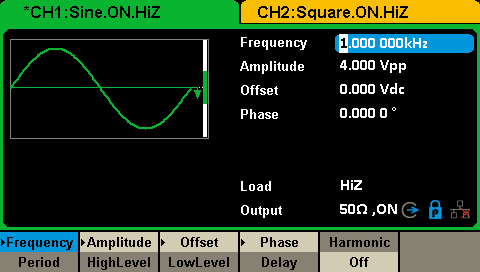

In [13]:
gen.get_screenshot()

In [14]:
glob.glob("generator*png")

['generator_screenshot_2025-09-19-14.32.12.png',
 'generator_screenshot_2025-09-19-14.28.10.png']

It also includes code to control some of the basic settings of the generator:

* `set_frequency(ch,f)`: Set frequency of channel `ch` (1 or 2) to `f` Hz
* `set_amplitude(ch, amp)`: Set amplitude of channel `ch` to `amp` Volts peak-to-peak
* `set_offset(ch, offset)`: Set offset of channel `ch` to `offset` Volts

In [16]:
gen.set_frequency(1,10e3)

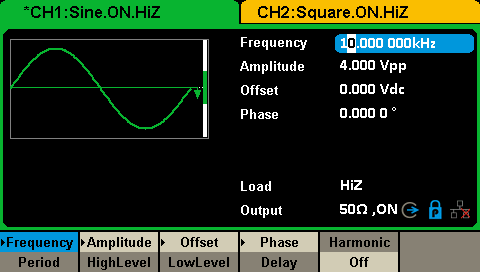

In [17]:
gen.get_screenshot()

## Programming the equipement to do more advanced stuff

The drivers above have only barely touched the surface of what is possible with controlling the instruments via USB! For a full list of all the possible things you can do, you can have a look at the programming manuals of the equipment:

https://nsweb.tn.tudelft.nl/~gsteele/tn2211/programming_manuals/

Intrument control and readout is all performed using text commands defined in the user manuals, (mostly) following the SCPI convention:

https://en.wikipedia.org/wiki/Standard_Commands_for_Programmable_Instruments

Typically, this involves reading the manual to understand the text command you need to send first. Once you have found what the command syntax is, you can use the built in `write()`, `read()`, `query()` commands. For example, to set the phase of the CH1 waveform in the generator to 10 degrees, the command looks like this:

In [19]:
gen.write("C1:BSWV PHSE,10")

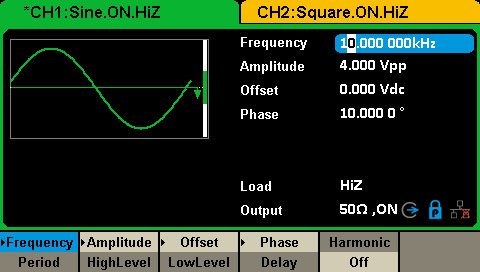

In [20]:
gen.get_screenshot()

As you can see in the driver source code, most functions are relatively simple, except for `get_trace` from the scope driver, which involves extraction of information from a relatively complex binary bitstream (Gary just copy-pasted the code from the user manual in the end to get it to work...). 

Feel free to poke around in the driver library code to see how the drivers work. 

If you dare, you are also welcome to add new functions to your copy of the driver library, and if you think they could be useful for other students, please let Gary know and we can create a pull request to integrate your code into the official driver! 